### Objective : 

* To identify which are the different factors that drive attrition.
* Make a model to predict the attrition. 

#### Data Dictionary
The data contains demographic details, work-related metrics and attrition flag.

* `EmployeeNumber` - Employee Identifier
* `Attrition` - Did the employee attrite?
* `Age` - Age of the employee
* `BusinessTravel` - Travel commitments for the job
* `DailyRate` - Data description not available**
* `Department` - Employee Department
* `DistanceFromHome` - Distance from work to home (in km)
* `Education` - 1-Below College, 2-College, 3-Bachelor, 4-Master,5-Doctor
* `EducationField` - Field of Education
* `EmployeeCount` - Employee Count in a row
* `EnvironmentSatisfaction` - 1-Low, 2-Medium, 3-High, 4-Very High
* `Gender` - Employee's gender
* `HourlyRate` - Data description not available**
* `JobInvolvement` - 1-Low, 2-Medium, 3-High, 4-Very High
* `JobLevel` - Level of job (1 to 5)
* `JobRole` - Job Roles
* `JobSatisfaction` - 1-Low, 2-Medium, 3-High, 4-Very High
* `MaritalStatus` - Marital Status
* `MonthlyIncome` - Monthly Salary
* `MonthlyRate` - Data description not available**
* `NumCompaniesWorked` - Number of companies worked at
* `Over18` - Over 18 years of age?
* `OverTime` - Overtime?
* `PercentSalaryHike` - The percentage increase in salary last year
* `PerformanceRating` - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* `RelationshipSatisfaction` - 1-Low, 2-Medium, 3-High, 4-Very High
* `StandardHours` - Standard Hours
* `StockOptionLevel` - Stock Option Level
* `TotalWorkingYears` - Total years worked
* `TrainingTimesLastYear` - Number of training attended last year
* `WorkLifeBalance` - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* `YearsAtCompany` - Years at Company
* `YearsInCurrentRole` - Years in the current role
* `YearsSinceLastPromotion` - Years since the last promotion
* `YearsWithCurrManager` - Years with the current manager

#### Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import scipy.stats as stats
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

### Data Exploration, Cleaning, Transformation, Feature Engineering

In [2]:
hr=pd.read_csv("data/26_HR_Employee_Attrition.csv")

In [3]:
# copying data to another varaible to avoid any changes to original data
data=hr.copy()

#### Review top and bottom 5 rows

In [4]:
data.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [5]:
data.tail()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2935,2936,No,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
2936,2937,No,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
2937,2938,No,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
2938,2939,No,49,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8
2939,2940,No,34,Travel_Rarely,628,Research & Development,8,3,Medical,1,...,1,80,0,6,3,4,4,3,1,2


#### Dataset Shape

In [6]:
data.shape

(2940, 35)

* The dataset has 2940 rows and 35 columns of data

#### Dataset Datatype

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            2940 non-null   int64 
 1   Attrition                 2940 non-null   object
 2   Age                       2940 non-null   int64 
 3   BusinessTravel            2940 non-null   object
 4   DailyRate                 2940 non-null   int64 
 5   Department                2940 non-null   object
 6   DistanceFromHome          2940 non-null   int64 
 7   Education                 2940 non-null   int64 
 8   EducationField            2940 non-null   object
 9   EmployeeCount             2940 non-null   int64 
 10  EnvironmentSatisfaction   2940 non-null   int64 
 11  Gender                    2940 non-null   object
 12  HourlyRate                2940 non-null   int64 
 13  JobInvolvement            2940 non-null   int64 
 14  JobLevel                

***Observations -***
* *There are no null values in the dataset.*
* *We can convert the object type columns to categories.*

*`converting "objects" to "category" reduces the data space required to store the dataframe`*

#### Fixing the data types

In [8]:
cols = data.select_dtypes(['object'])
print(cols.columns)

for i in cols.columns:
    data[i] = data[i].astype('category')

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeNumber            2940 non-null   int64   
 1   Attrition                 2940 non-null   category
 2   Age                       2940 non-null   int64   
 3   BusinessTravel            2940 non-null   category
 4   DailyRate                 2940 non-null   int64   
 5   Department                2940 non-null   category
 6   DistanceFromHome          2940 non-null   int64   
 7   Education                 2940 non-null   int64   
 8   EducationField            2940 non-null   category
 9   EmployeeCount             2940 non-null   int64   
 10  EnvironmentSatisfaction   2940 non-null   int64   
 11  Gender                    2940 non-null   category
 12  HourlyRate                2940 non-null   int64   
 13  JobInvolvement            2940 non-null   int64 

***Data Memory Ssage has reduced from 804 KB to 624.4 KB***

#### Statistical Summary

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeNumber,2940.0,1470.500000,848.849221,1.0,735.75,1470.5,2205.25,2940.0
Age,2940.0,36.923810,9.133819,18.0,30.00,36.0,43.00,60.0
DailyRate,2940.0,802.485714,403.440447,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,2940.0,9.192517,8.105485,1.0,2.00,7.0,14.00,29.0
Education,2940.0,2.912925,1.023991,1.0,2.00,3.0,4.00,5.0
EmployeeCount,2940.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,2940.0,2.721769,1.092896,1.0,2.00,3.0,4.00,4.0
HourlyRate,2940.0,65.891156,20.325969,30.0,48.00,66.0,84.00,100.0
JobInvolvement,2940.0,2.729932,0.711440,1.0,2.00,3.0,3.00,4.0
JobLevel,2940.0,2.063946,1.106752,1.0,1.00,2.0,3.00,5.0


* *`EmployeeNumber` is an ID variable and not useful for predictive modelling.*
* *Age of the employees range from 18 to 60 years and the average age is 36 years.*
* *`EmployeeCount` has only 1 as the value in all the rows and can be dropped as it will not be adding any information to our analysis.*
* *`StandardHours` has only 80 as the value in all the rows and can be dropped as it will not be adding any information to our analysis.*
* *`HourlyRate` has a huge range, but we do not know what this variable stands for, yet. The same goes for daily and monthly rates.*

In [11]:
data.describe(include=['category']).T

,count,unique,top,freq
Attrition,2940,2,No,2466
BusinessTravel,2940,3,Travel_Rarely,2086
Department,2940,3,Research & Development,1922
EducationField,2940,6,Life Sciences,1212
Gender,2940,2,Male,1764
JobRole,2940,9,Sales Executive,652
MaritalStatus,2940,3,Married,1346
Over18,2940,1,Y,2940
OverTime,2940,2,No,2108


* *`Attrition` is our target variable with 84% records 'No' or employee will not attrite.*
* *Majority of the employees have low business travel requirements*
* *Majority of the employees are from the Research and Development department.*
* *`Over18` All employees are over 18 years of age -  we can drop this variable as it will not be adding any information to our analysis.*
* *There are more male employees than female employees.*

**Dropping columns which are not adding any information.**

In [12]:
data.drop(['EmployeeNumber','EmployeeCount','StandardHours','Over18'],axis=1,inplace=True)

**Let's look at the unqiue values of all the categories**

In [13]:
cols_cat= data.select_dtypes(['category'])

In [14]:
for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in Attrition are :
Attrition
No     2466
Yes     474
Name: count, dtype: int64
**************************************************
Unique values in BusinessTravel are :
BusinessTravel
Travel_Rarely        2086
Travel_Frequently     554
Non-Travel            300
Name: count, dtype: int64
**************************************************
Unique values in Department are :
Department
Research & Development    1922
Sales                      892
Human Resources            126
Name: count, dtype: int64
**************************************************
Unique values in EducationField are :
EducationField
Life Sciences       1212
Medical              928
Marketing            318
Technical Degree     264
Other                164
Human Resources       54
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
Male      1764
Female    1176
Name: count, dtype: int64
**************************************************
Unique va

### Exploratory Data Analysis

#### Univariate Analysis

**Helper Functions**

In [15]:
# Function to create a histogram and boxplot combined for visualization of numerical features for Univariate Analysis
def num_analysis_hist_box(data, feature, figsize=(10, 5)):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)  # creating the 2 subplots
    
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="lightgreen")  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, color='skyblue')  # For histogram
    
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

In [16]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(12, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

`Age`

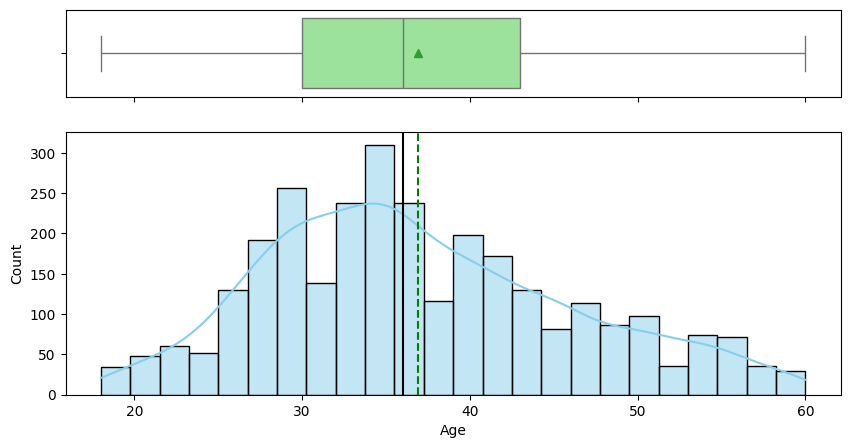

In [17]:
num_analysis_hist_box(data, 'Age')

*Very close to normal distribution*

`DailyRate`

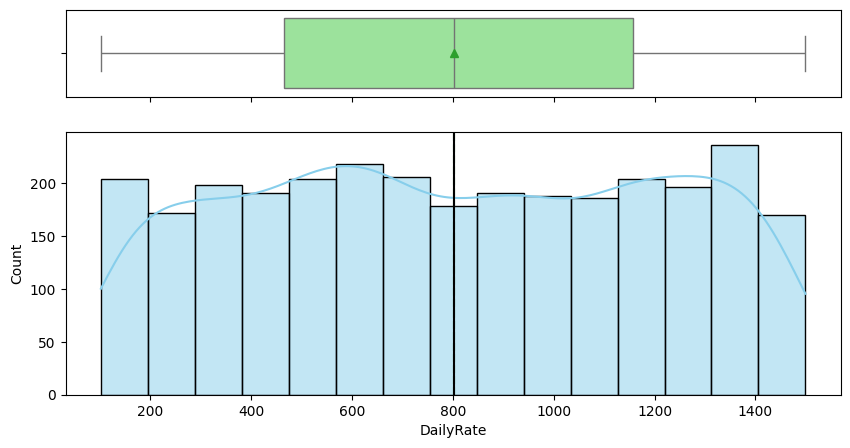

In [18]:
num_analysis_hist_box(data, 'DailyRate')

*Again fairly normal distribution*

`DistanceFromHome`

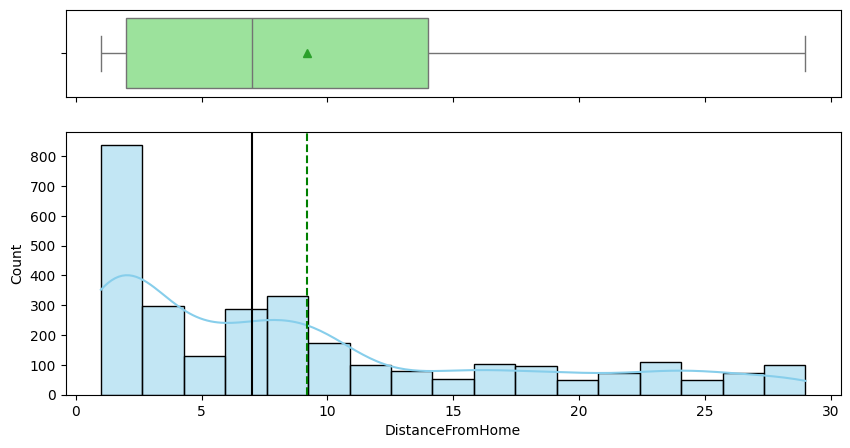

In [19]:
num_analysis_hist_box(data, 'DistanceFromHome')

*Right Skewed, 50% of the folks stay within 6-7 KM*

`HourlyRate`

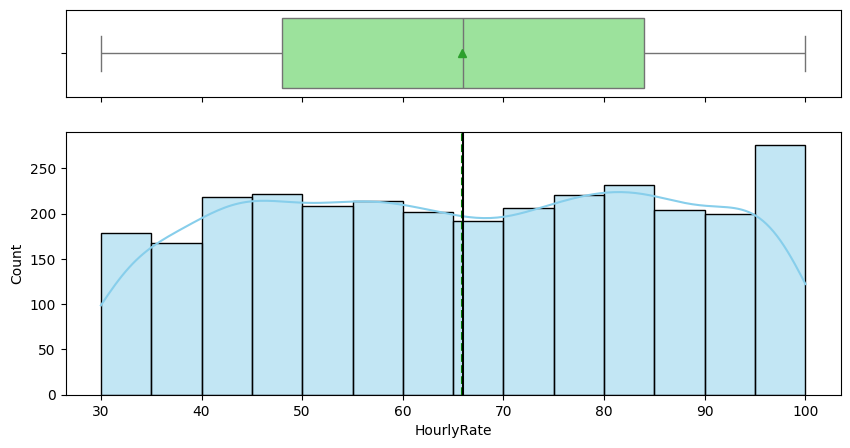

In [20]:
num_analysis_hist_box(data, 'HourlyRate')

*Mostly Uniformly Distributed*

`MonthlyIncome`

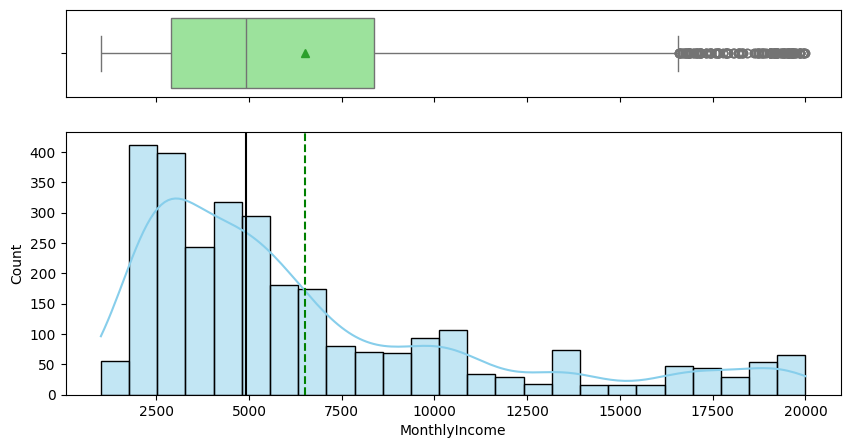

In [21]:
num_analysis_hist_box(data, 'MonthlyIncome')

*Right Skewed, 50% earn less than 5K*

`MonthlyRate`

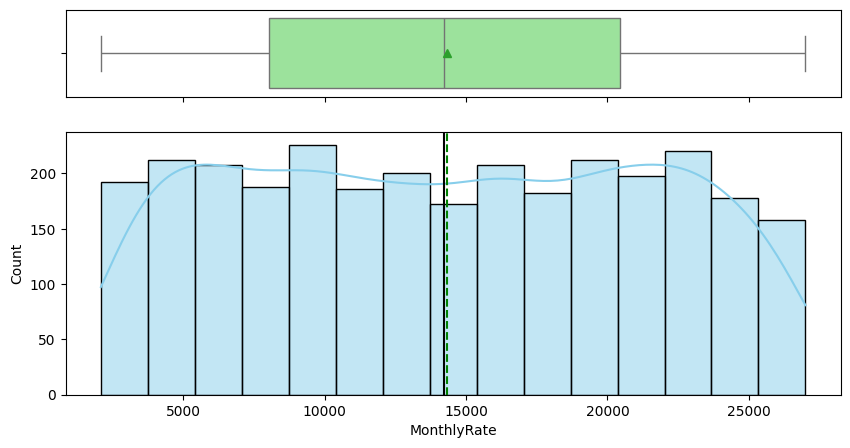

In [22]:
num_analysis_hist_box(data, 'MonthlyRate')

*Fairly Uniform Distribution*

`NumCompaniesWorked`

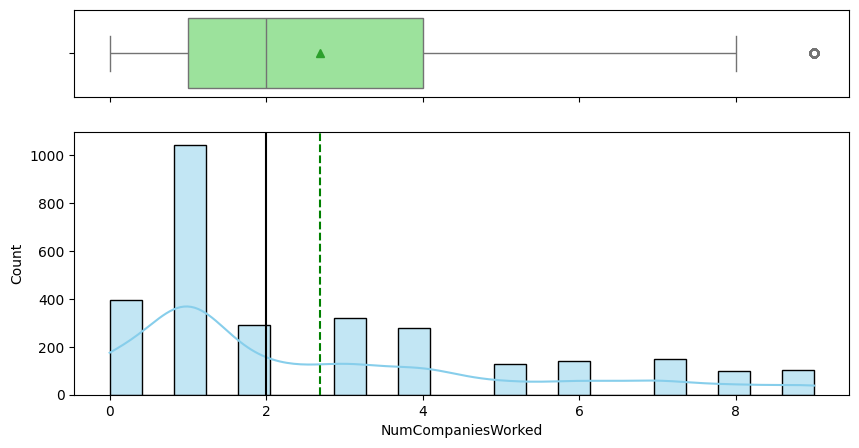

In [23]:
num_analysis_hist_box(data, 'NumCompaniesWorked')

*Most have people have worked for 1 company, Median is 2*

`PercentSalaryHike`

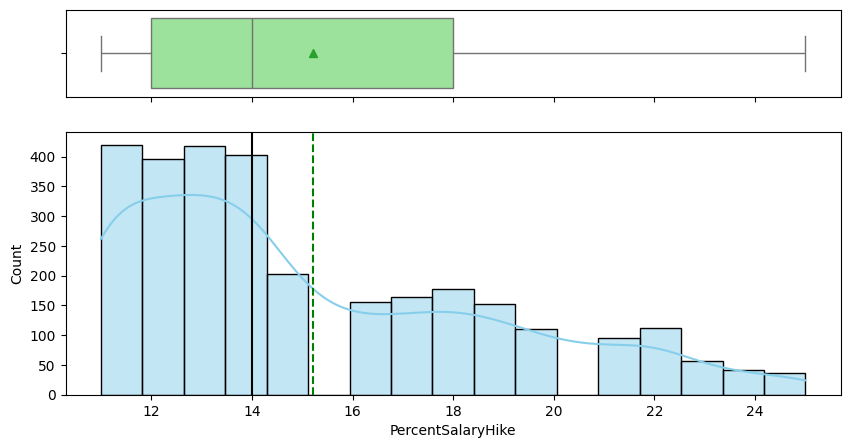

In [24]:
num_analysis_hist_box(data, 'PercentSalaryHike')

*Right Skewed Data, Median is 14*

`TotalWorkingYears`

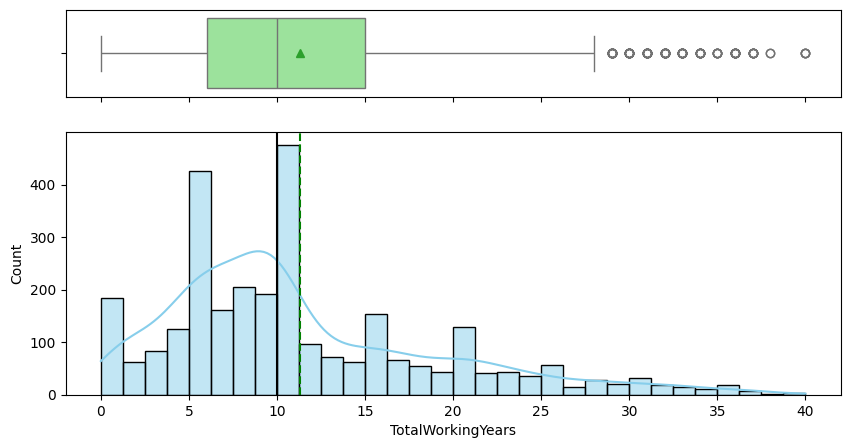

In [25]:
num_analysis_hist_box(data, 'TotalWorkingYears')

*Right Skewed, Median is 10. There are few outliers who have work exp more than 27*

`YearsAtCompany`

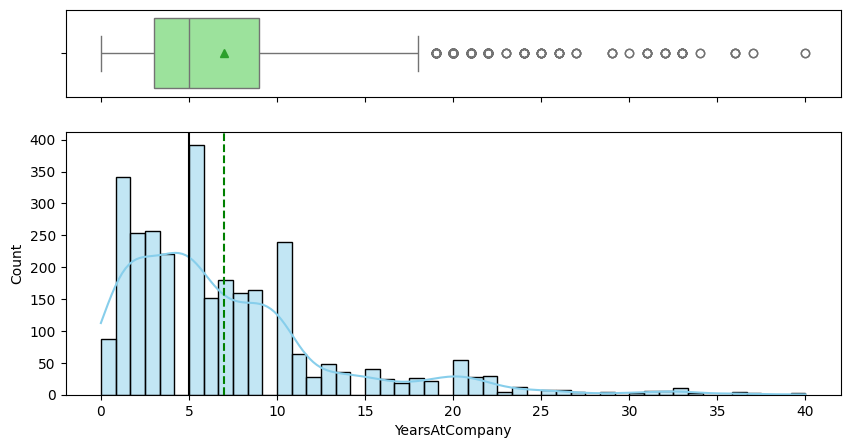

In [26]:
num_analysis_hist_box(data, 'YearsAtCompany')

*Right Skewed, Median is 5, outliers who have worked for more than 17-18 years*

`YearsInCurrentRole`

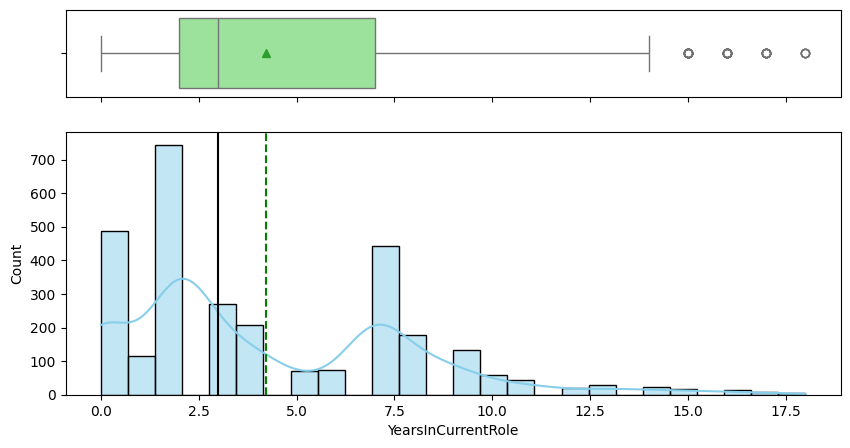

In [27]:
num_analysis_hist_box(data, 'YearsInCurrentRole')

*Right Skewed, Median is 3, there are few outliers who are in same role for more than 13 yrs*

`YearsSinceLastPromotion`

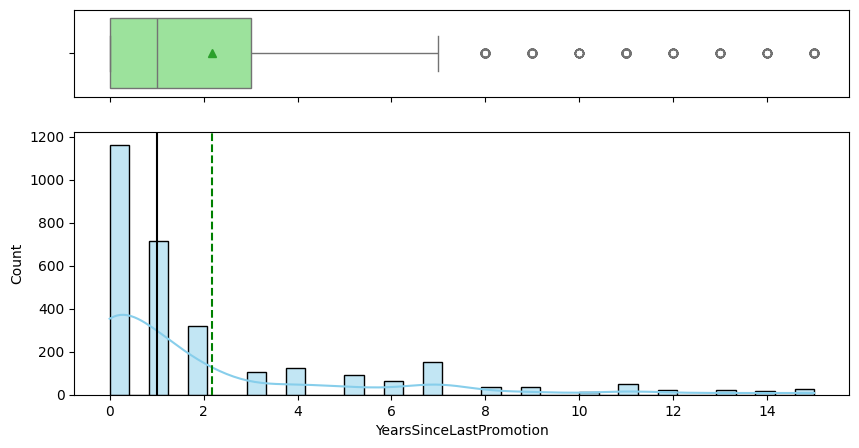

In [28]:
num_analysis_hist_box(data, 'YearsSinceLastPromotion')

*Right Skewed, Median is 1, mean is close to 2, but there are outliers with greater than 7 years*

`YearsWithCurrManager`

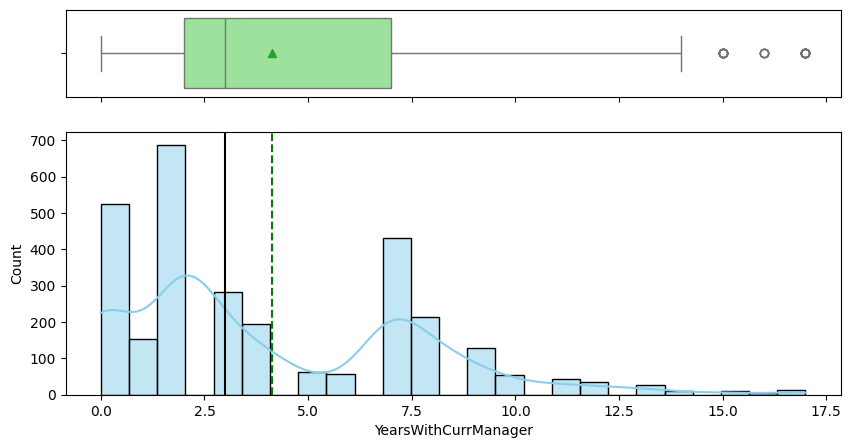

In [29]:
num_analysis_hist_box(data, 'YearsWithCurrManager')

*Right Skewed, Median is close to 3, mean is 4, outliers with more than 13 yrs*

`BusinessTravel`

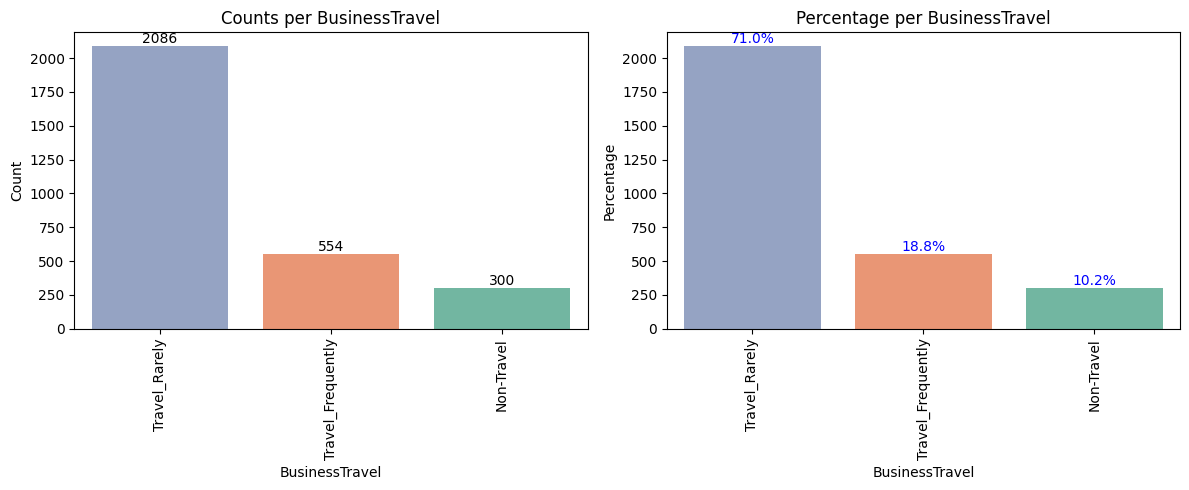

In [30]:
cat_analysis_count_and_perct(data, 'BusinessTravel')

*Majority have travelled rarely almost 71%*

`Department`

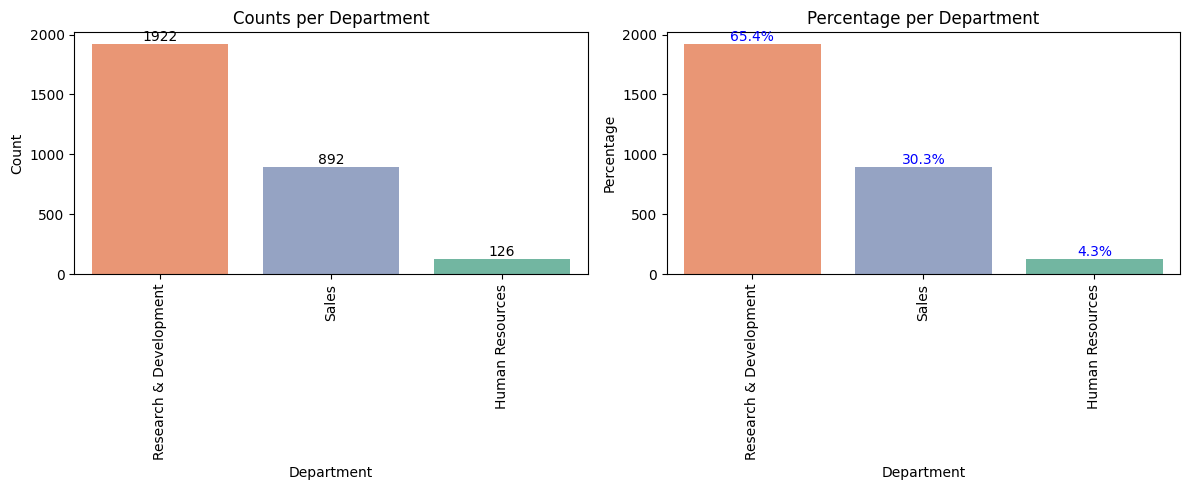

In [31]:
cat_analysis_count_and_perct(data, 'Department')

*Majority are working in Research and Development almost 65%*

`EducationField`

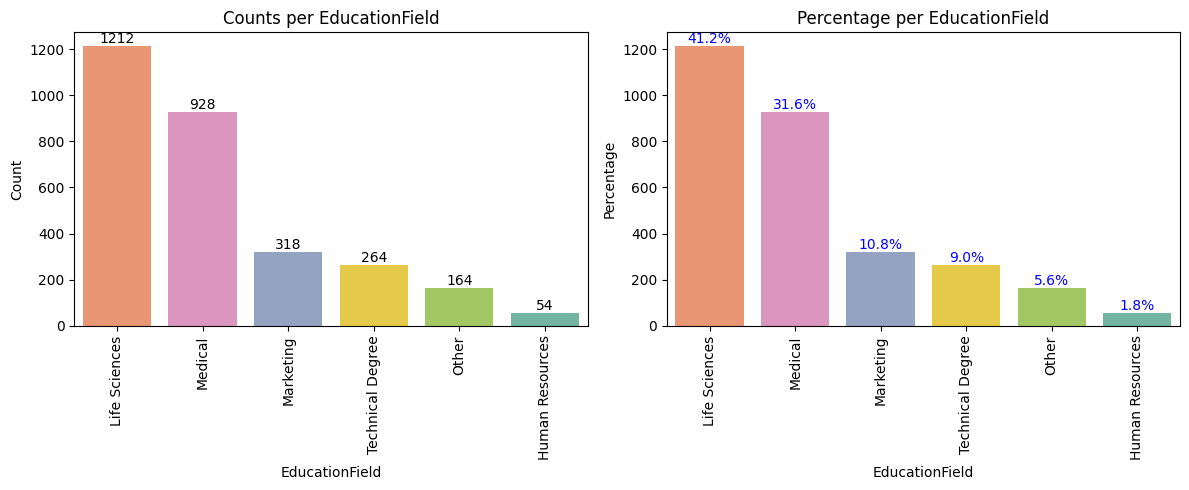

In [32]:
cat_analysis_count_and_perct(data, 'EducationField')

*41% are from Life Sciences followed by 32% from Medical*

`Gender`

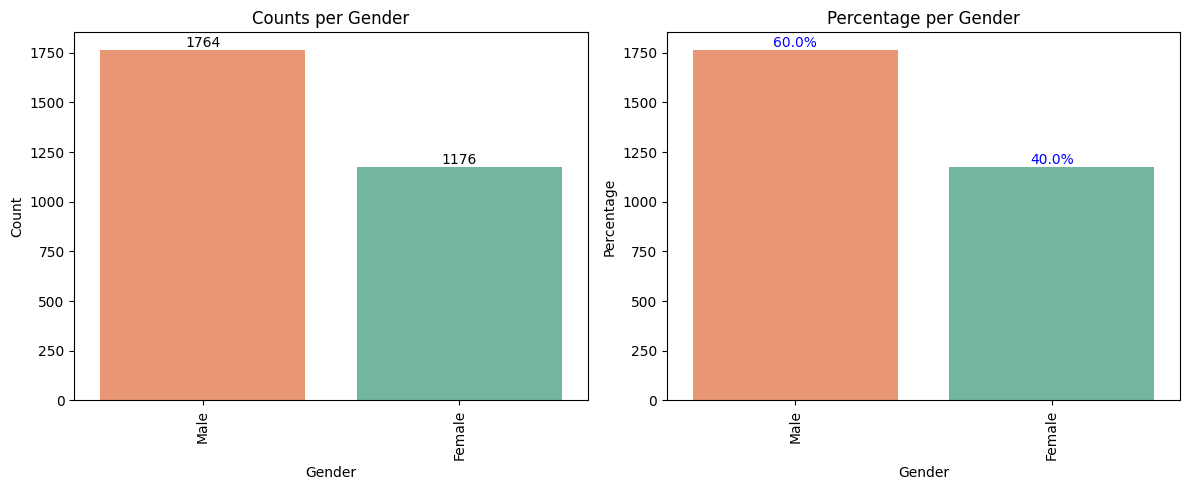

In [33]:
cat_analysis_count_and_perct(data, 'Gender')

*Majority are Males 60%*

`JobRole`

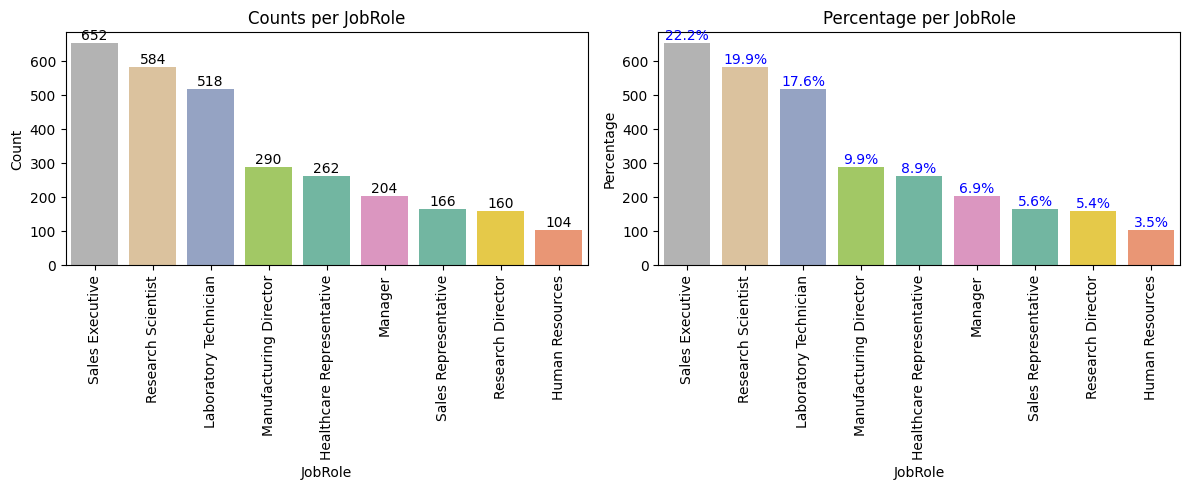

In [34]:
cat_analysis_count_and_perct(data, 'JobRole')

*Good Distribution of Job Roles, with Sales Executive leading with 22% followed by Research Scientist at 20%*

`MaritalStatus`

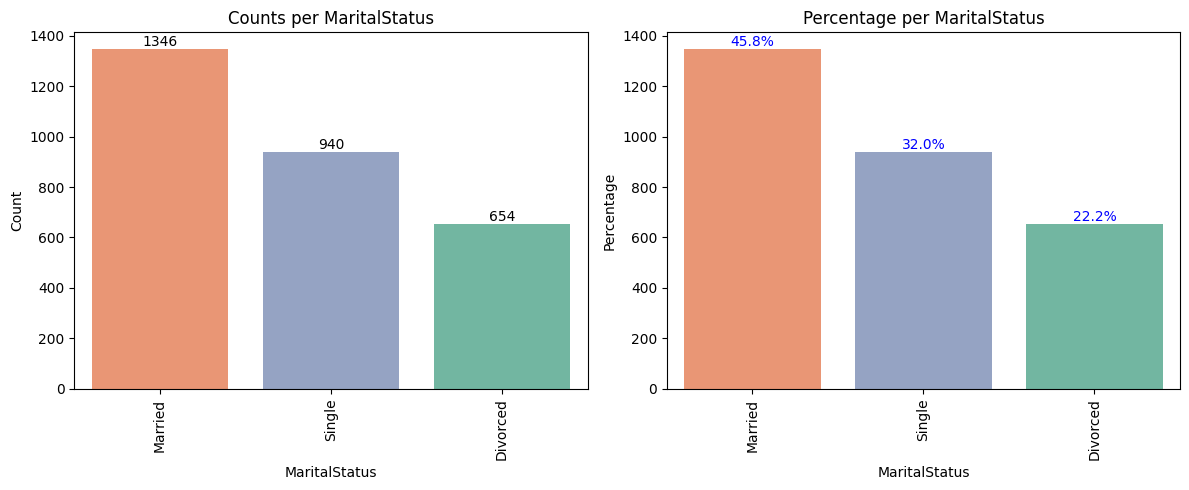

In [35]:
cat_analysis_count_and_perct(data, 'MaritalStatus')

*Majority are Married 46%, 32% are Single, 22% are Divorced*

`OverTime`

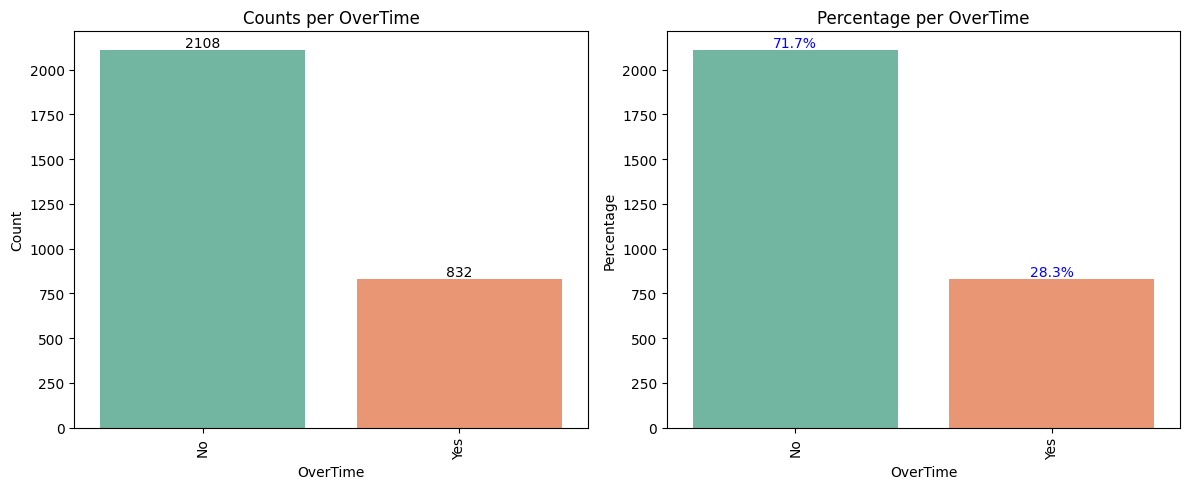

In [36]:
cat_analysis_count_and_perct(data, 'OverTime')

*Majority not working overtime, 72%*

`Attrition`

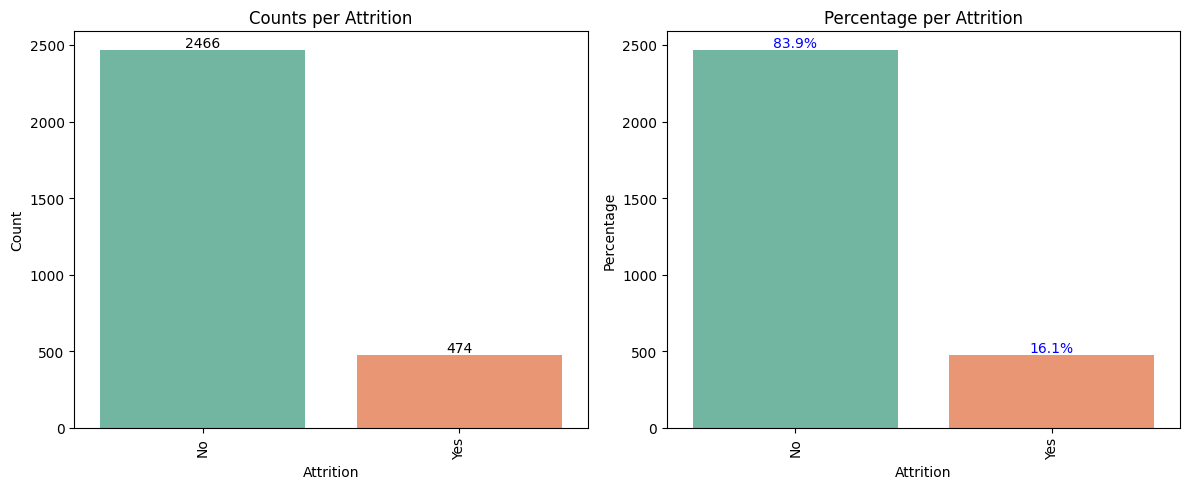

In [37]:
cat_analysis_count_and_perct(data, 'Attrition')

*Imbalanced data, with 16% Attrition potential *

#### Bivariate Analysis

**Helper Function**

In [38]:
### function to plot distributions wrt target
def num_feature_vs_target(data, predictor, target):
    sns.boxplot(data=data, x=target, y=predictor, palette="Set2", hue=target, showfliers=False);
    plt.title(f'{predictor} distribution by {target}');
    plt.tight_layout()
    plt.show()


In [39]:
# Function to plot target distribution by category with percentage labels on stacked bar segments
def target_distribution_by_category(data, x_col, hue_col, colormap='tab20', figsize=(6, 5), title=None):
    """
    Plots a stacked bar chart showing percentage distribution of hue_col within each x_col category,
    with percentage labels on each segment.
    """
    # Group and calculate percentages
    grouped = data.groupby([x_col, hue_col]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels
    for i, (index, row) in enumerate(percentages.iterrows()):
        cum_height = 0
        for j, value in enumerate(row):
            if value > 0:
                ax.text(
                    i,                      # x position
                    cum_height + value / 2, # y position (middle of the bar segment)
                    f'{value:.1f}%',        # label text
                    ha='center', va='center', fontsize=8, color='white'
                )
                cum_height += value

    plt.ylabel('Percentage')
    plt.title(title or f'{x_col} Distribution by {hue_col} (Stacked Percentage)')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#### Attrition vs Earnings of employee

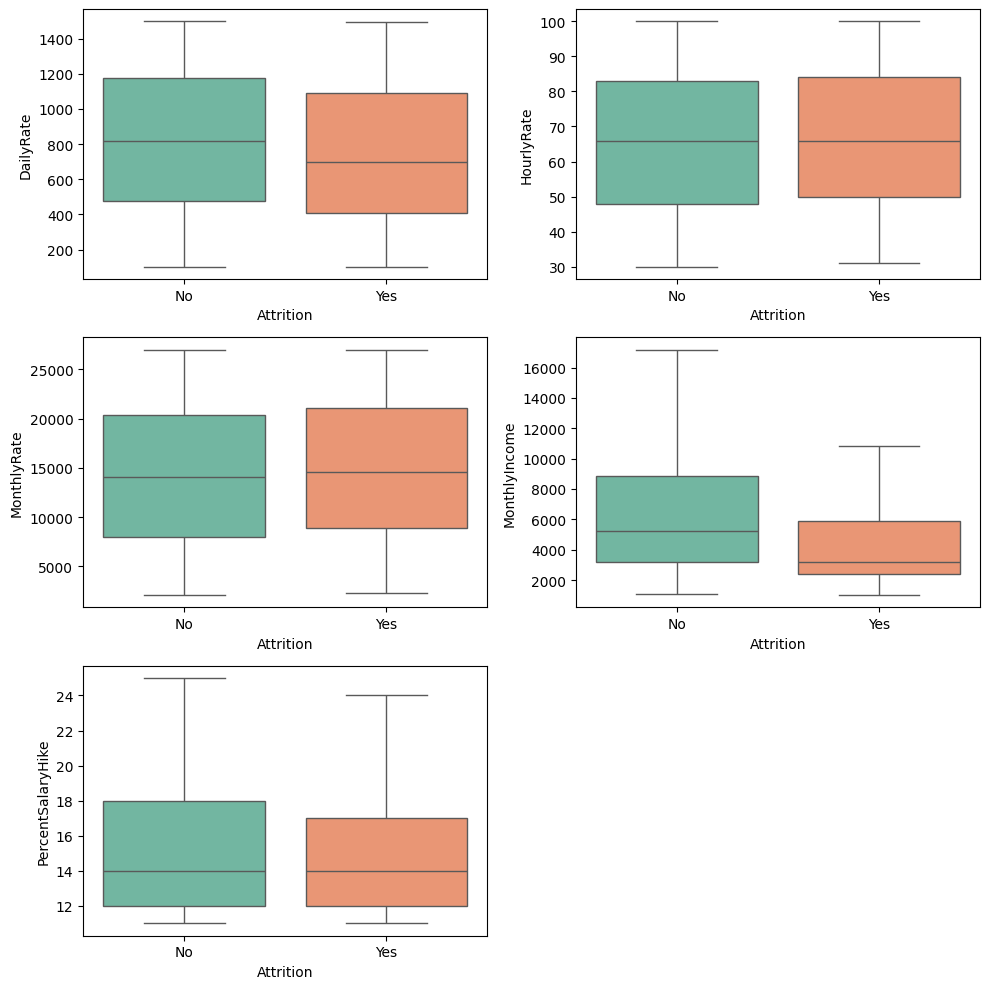

In [40]:
cols = data[['DailyRate','HourlyRate','MonthlyRate','MonthlyIncome','PercentSalaryHike']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=data, x="Attrition", y=variable, palette="Set2", hue="Attrition", showfliers=False);
    plt.tight_layout()
plt.show()

*Employees having lower Daily rate and less monthly wage are more likely to quit*

#### Attrition vs Years working in company

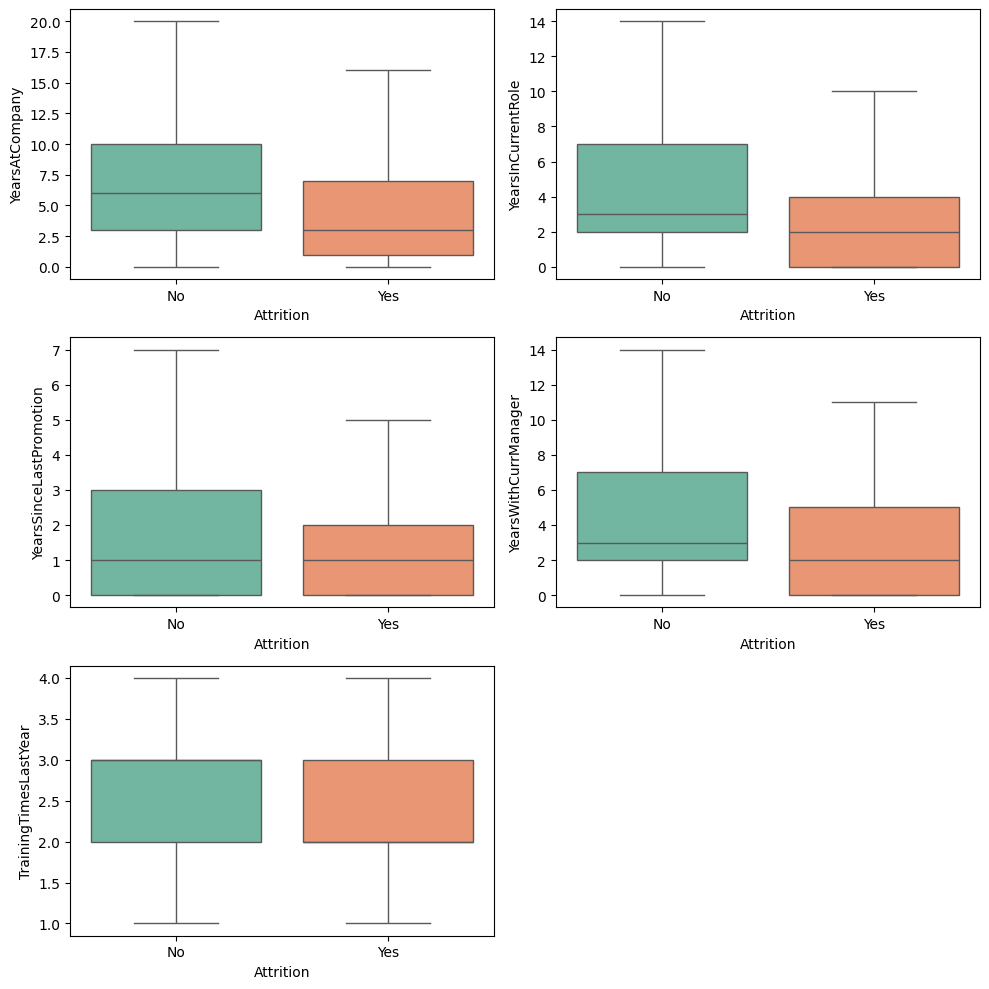

In [41]:
cols = data[['YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager','TrainingTimesLastYear']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=data, x="Attrition", y=variable, palette="Set2", hue="Attrition", showfliers=False);
    plt.tight_layout()
plt.show()

*Those employees who have spent less time at a company in a current role or with a manager have higher chances of attriting.*

#### Attrition vs Previous job roles

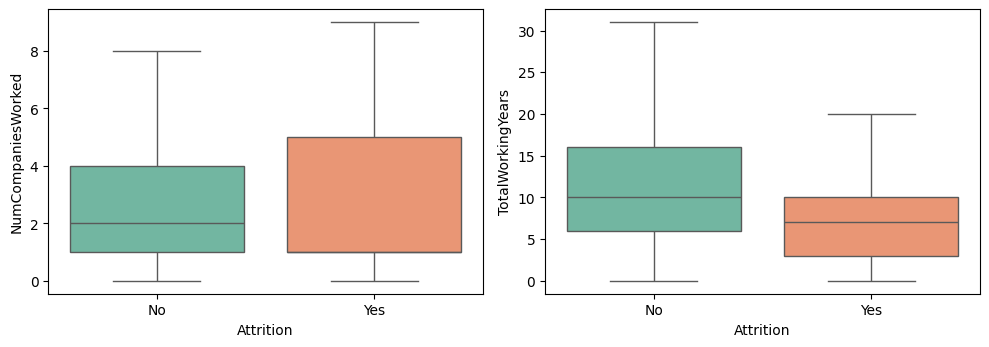

In [42]:
cols = data[['NumCompaniesWorked','TotalWorkingYears']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=data, x="Attrition", y=variable, palette="Set2", hue="Attrition", showfliers=False);
    plt.tight_layout()
plt.show()

*Employees with less working years in the company are likely to quit*

#### BusinessTravel vs Attrition

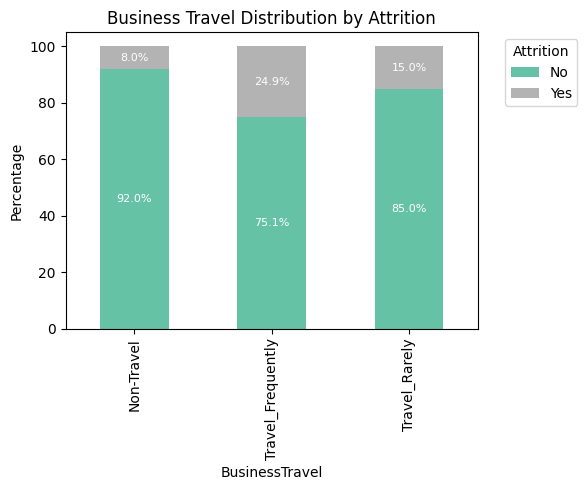

In [43]:
target_distribution_by_category(data, x_col='BusinessTravel', hue_col='Attrition', colormap='Set2', figsize=(6, 5), title='Business Travel Distribution by Attrition')

*Employees who have to travel more, are likely to quit*

#### Department vs Attrition

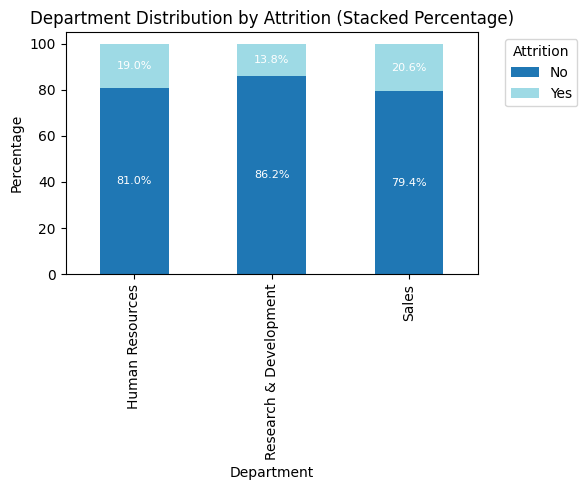

In [44]:
target_distribution_by_category(data, x_col='Department', hue_col='Attrition')

*Sales Employees are likely to quit compared to Human Resources and Research and Dev*

#### EducationField vs Attrition

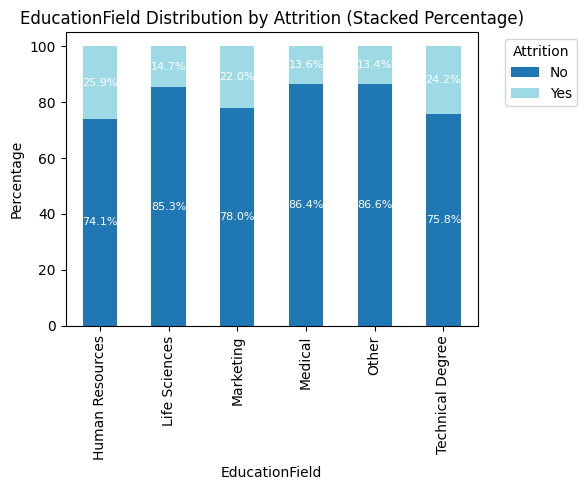

In [45]:
target_distribution_by_category(data, x_col='EducationField', hue_col='Attrition')

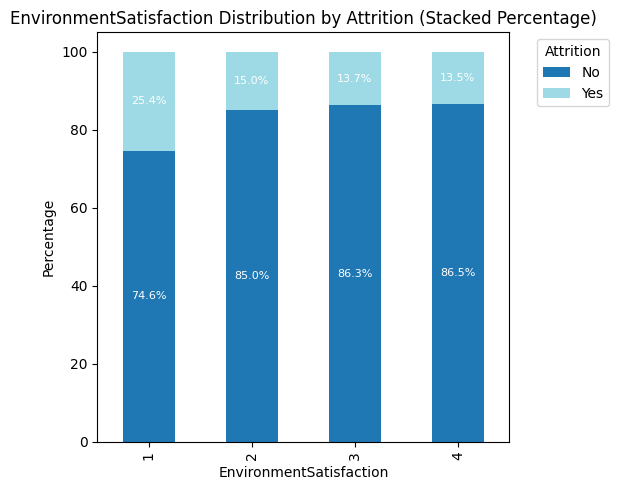

In [46]:
target_distribution_by_category(data, x_col='EnvironmentSatisfaction', hue_col='Attrition')

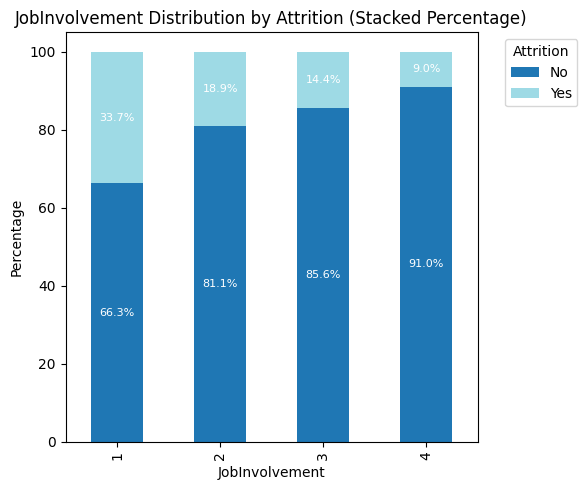

In [47]:
target_distribution_by_category(data,"JobInvolvement","Attrition")

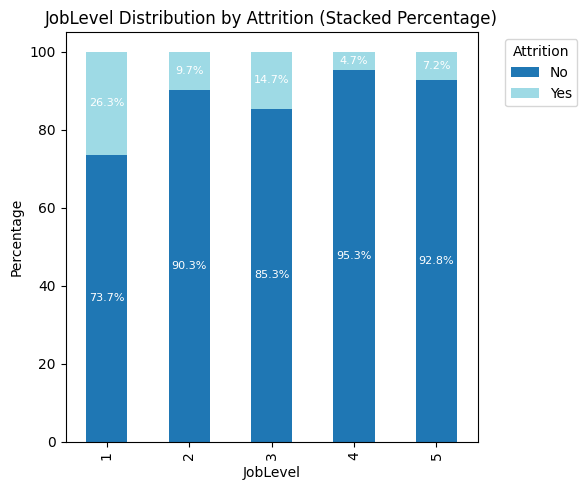

In [48]:
target_distribution_by_category(data,"JobLevel","Attrition")

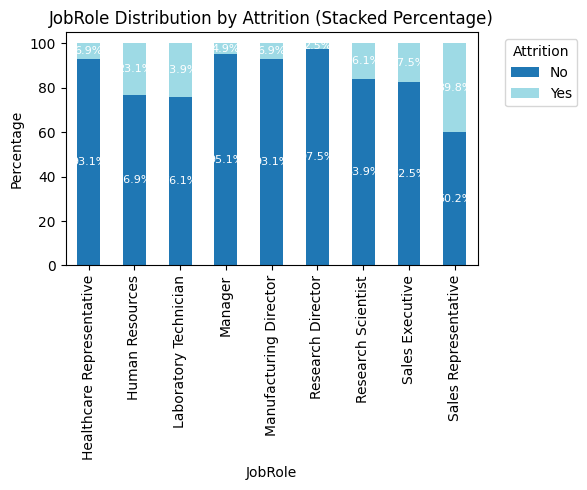

In [49]:
target_distribution_by_category(data,"JobRole","Attrition")

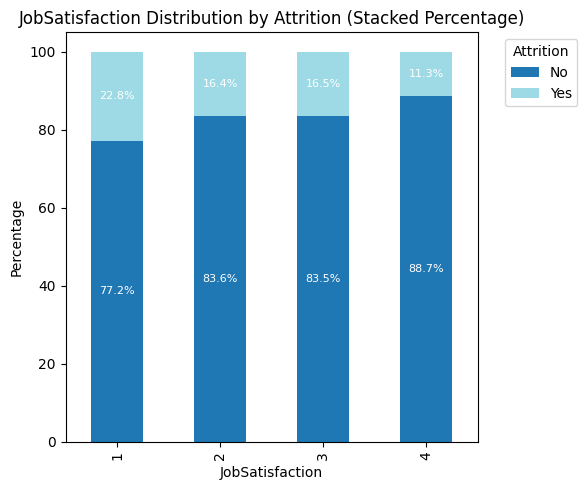

In [50]:
target_distribution_by_category(data,"JobSatisfaction","Attrition")

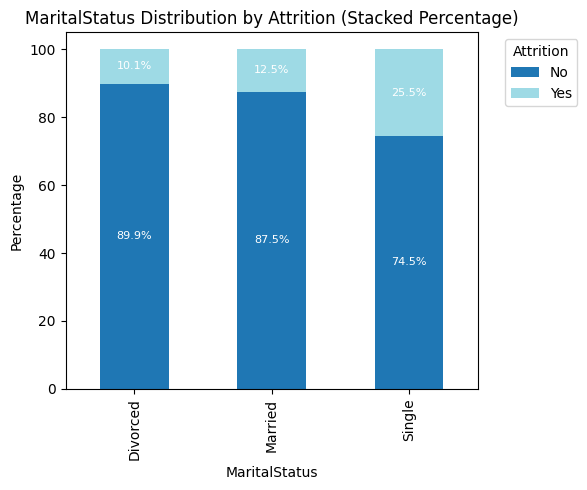

In [51]:
target_distribution_by_category(data,"MaritalStatus","Attrition")

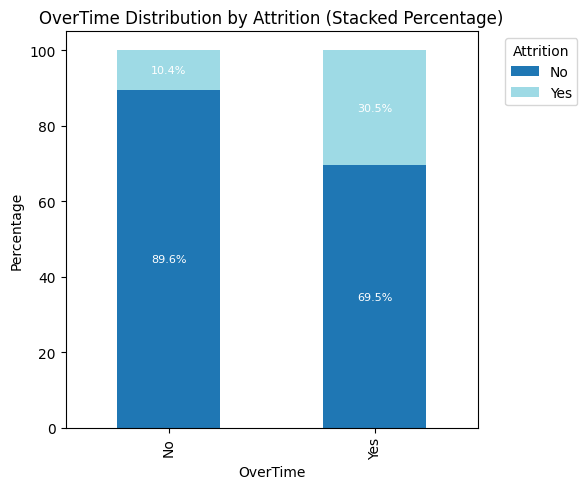

In [52]:
target_distribution_by_category(data,"OverTime","Attrition")

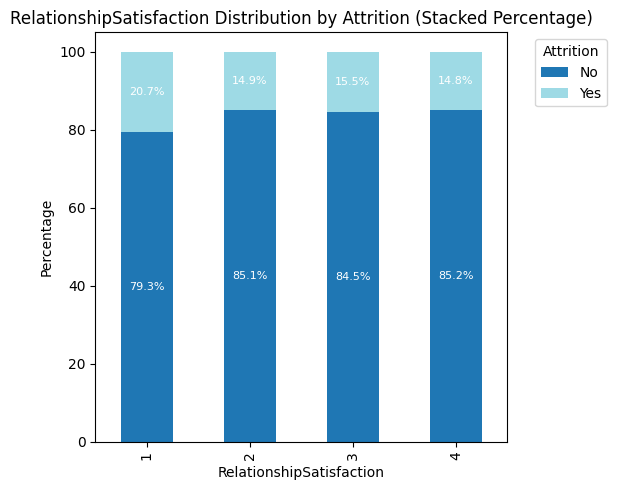

In [53]:
target_distribution_by_category(data,"RelationshipSatisfaction","Attrition")

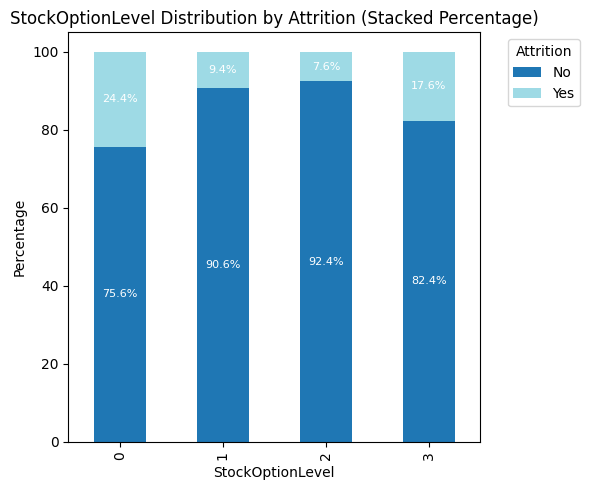

In [54]:
target_distribution_by_category(data,"StockOptionLevel","Attrition")

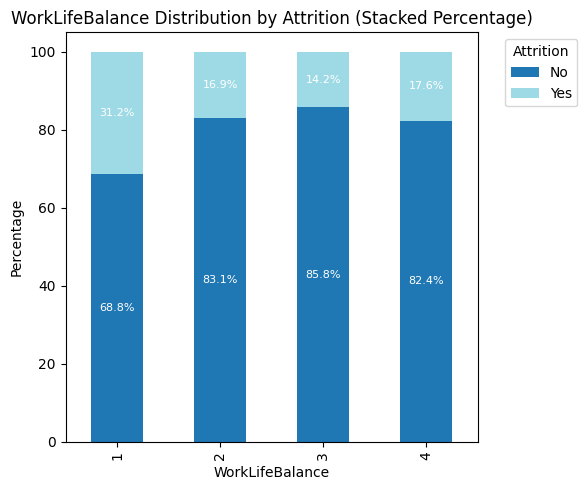

In [55]:
target_distribution_by_category(data,"WorkLifeBalance","Attrition")

**Observations from EDA:**

* `age`: The variable Age is normally distributed with an average equal to 37 years. Age is positively correlated JobLevel and Education (i.e., the older an employee is, the more educated and at a higher job level they are).
* `DailyRate`: It is having a fairly uniform distribution with an average of 800. Employees having lower Daily rates and less monthly wage are more likely to attrite.
* `DistanceFromHome`: This shows a right-skewed distribution. Most people stay at a close distance from home with few also leaving away from work. Employees who have to travel a more distance from their home attrite more.
* `HourlyRate`: It is an almost uniformly distributed variable. It has mean and median approx equal to 65. The hourly rate doesn't have much impact on attrition.
* `MonthlyIncome`: Monthly Income distribution is almost right-skewed. Few employees are earning much higher than the rest of the employees.  MonthlyIncome is highly correlated to Job Level (0.95). 
* `MonthlyRate`: It is a uniformly distributed variable with a median close to 14500. The monthly rate doesn't have much impact on attrition.
* `NumCompaniesWorked`: On average people have worked at 2.5 companies with a median of 2 companies. The majority of people have worked in only one company. Approx 350 people are freshers. There are employees worked at 9 companies. They will be the outliers.
* `PercentSalaryHike`:  It has a right-skewed distribution. It is correlated with performance rating with a coefficient of 0.77. Lesser salary hike also contributes to attrition.
* `TotalWorkingYears`: Work experience is having a significant right skew. It also contains few outliers.
* `YearsAtCompany`: Significantly skewed towards the right. Also contains outliers.
* `YearsInCurrentRole`: It is having few outliers. The lower whisker coincides with the first quartile.
* `YearsWithCurrManager`: It is a right-skewed variable with few outliers too.
* `BusinessTravel`: Almost 71% of employees have travel rarely and 19% travel frequently. As the travel frequency increases of an employee increases, the Attrition rate increases. There's a ~22% probability of employees attriting who travel frequently.
* `Department`: The R&D department consists of almost 65% of employees.
* `EducationField`:People with Life science background is dominant over others with almost 41% count.
* `Gender`: 60% of people are male while the rest are female.
* `JobRole`: Almost 22% of people are sales executives followed by 20% research scientists.
* `MaritalStatus`: Almost 46% of people are married and 32% are single.
* `OverTime`: Only almost 29% of people are ready to do overtime. Employees who work overtime tend to attrite more. There a ~35% probability of attrition among employees working overtime.
* `Attrition`: There's an imbalance in the data with 16% of the employees attriting and rest not.

### Model Building

#### Split Data

In [56]:
X = data.drop(['Attrition'],axis=1)
X = pd.get_dummies(X,drop_first=True)
y = data['Attrition'].map({'Yes': 1, 'No': 0})

In [57]:
# Splitting data into training and test set:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)
print(X_train.shape, X_test.shape)

(2058, 44) (882, 44)


In [58]:
y.value_counts(1)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [59]:
y_test.value_counts(1)

Attrition
0    0.839002
1    0.160998
Name: proportion, dtype: float64

#### Model evaluation criterion

**Model can make wrong predictions as:**
1. Predicting an employee will attrite and the employee doesn't attrite - False Positive
2. Predicting an employee will not attrite and the employee attrites - False Negative

**Which case is more important?**
* Predicting that employee will not attrite but he attrites i.e. losing on a valuable employee or asset. Reduce False Negative. Increase Recall 

**Helper Function**

In [60]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [61]:
# Confusion Matrix for classification
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

### 1. Decision Tree

In [62]:
dtree = DecisionTreeClassifier(criterion='gini',class_weight={0:0.17,1:0.83},random_state=1) # Class 0 is given weight 0.17 and Class 1 is given weight 0.83

In [63]:
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.17, 1: 0.83}"


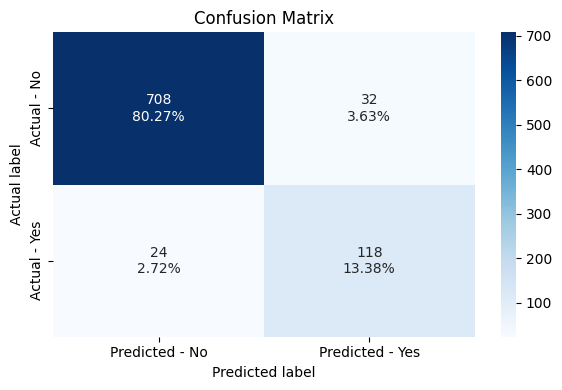

In [64]:
confusion_matrix_sklearn(dtree, X_test, y_test)

In [65]:
dtree_model_train_perf=model_performance_classification_sklearn(dtree, X_train, y_train)
print("Training performance \n",dtree_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [66]:
dtree_model_test_perf=model_performance_classification_sklearn(dtree, X_test, y_test)
print("Testing performance \n",dtree_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.936508  0.830986   0.786667  0.808219


*Decision tree is working well on the training data but is not able to generalize well on the test data concerning the recall.*

### 2. Bagging Classifier

In [67]:
bagging = BaggingClassifier(random_state=1)
bagging.fit(X_train,y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1
,verbose,0


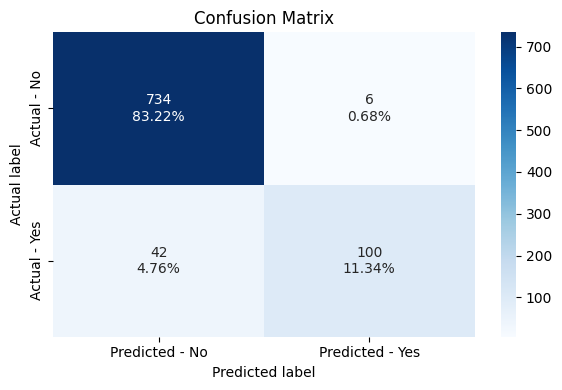

In [68]:
confusion_matrix_sklearn(bagging, X_test, y_test)

In [69]:
bagging_model_train_perf=model_performance_classification_sklearn(bagging, X_train, y_train)
print("Training performance \n",bagging_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.993197  0.957831        1.0  0.978462


In [70]:
bagging_model_test_perf=model_performance_classification_sklearn(bagging, X_test, y_test)
print("Testing performance \n",bagging_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.945578  0.704225   0.943396  0.806452


*Bagging classifier is overfitting on the training set and is performing poorly on the test set in terms of recall.*

### 3. Bagging Classifier with weighted decision tree

In [71]:
bagging_wt = BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini',class_weight={0:0.17,1:0.83},random_state=1),random_state=1)
bagging_wt.fit(X_train,y_train)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1
,verbose,0


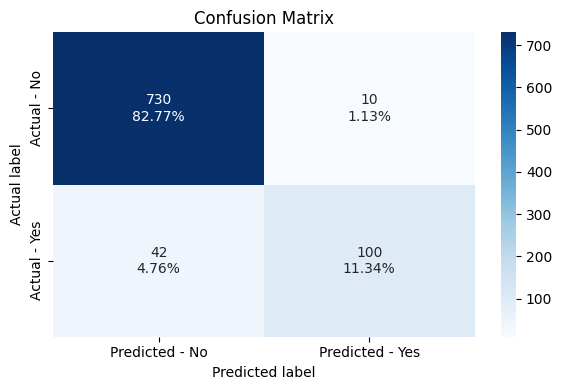

In [72]:
confusion_matrix_sklearn(bagging_wt,X_test,y_test)

In [73]:
bagging_wt_model_train_perf=model_performance_classification_sklearn(bagging_wt,X_train,y_train)
print("Training performance \n",bagging_wt_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.993197  0.957831        1.0  0.978462


In [74]:
bagging_wt_model_test_perf=model_performance_classification_sklearn(bagging_wt, X_test, y_test)
print("Testing performance \n",bagging_wt_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.941043  0.704225   0.909091  0.793651


*Bagging classifier with a weighted decision tree is giving very good accuracy and prediction but is not able to generalize well on test data in terms of recall.*

### 4. Random Forest

In [75]:
rf = RandomForestClassifier(random_state=1)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


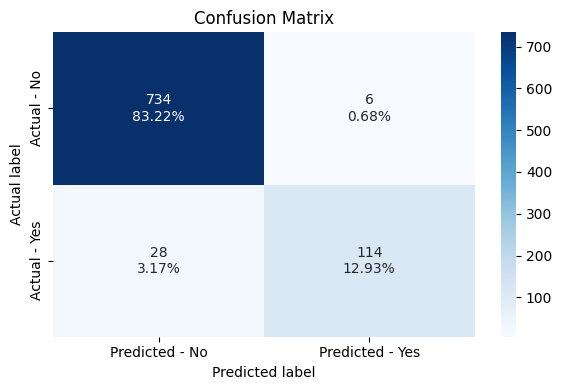

In [76]:
confusion_matrix_sklearn(rf,X_test,y_test)

In [77]:
rf_model_train_perf=model_performance_classification_sklearn(rf,X_train,y_train)
print("Training performance \n",rf_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [78]:
rf_model_test_perf=model_performance_classification_sklearn(rf,X_test,y_test)
print("Testing performance \n",rf_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.961451  0.802817       0.95  0.870229


*Random Forest has performed well in terms of accuracy and precision, but it is not able to generalize well on the test data in terms of recall.*

### 5. Random forest with class weights

In [79]:
rf_wt = RandomForestClassifier(class_weight={0:0.17,1:0.83}, random_state=1)
rf_wt.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


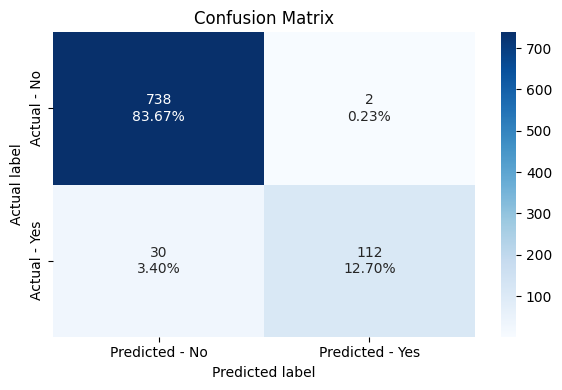

In [80]:
confusion_matrix_sklearn(rf_wt, X_test,y_test)

In [81]:
rf_wt_model_train_perf=model_performance_classification_sklearn(rf_wt, X_train,y_train)
print("Training performance \n",rf_wt_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [82]:
rf_wt_model_test_perf=model_performance_classification_sklearn(rf_wt, X_test,y_test)
print("Testing performance \n",rf_wt_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision     F1
0  0.963719  0.788732   0.982456  0.875


* There is not much improvement in metrics of weighted random forest as compared to the unweighted random forest.

#### Tuning Models

### 6. Using GridSearch for Hyperparameter tuning Decision Tree

In [83]:
# Choose the type of classifier. 
dtree_estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2,30), 
              'min_samples_leaf': [1, 2, 5, 7, 10],
              'max_leaf_nodes' : [2, 3, 5, 10,15, None],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
dtree_estimator.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(19)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0001
,class_weight,None


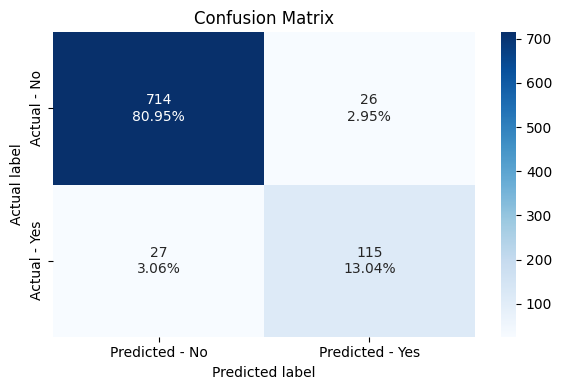

In [84]:
confusion_matrix_sklearn(dtree_estimator, X_test,y_test)

In [85]:
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator, X_train,y_train)
print("Training performance \n",dtree_estimator_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.996599  0.978916        1.0  0.989346


In [86]:
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator, X_test, y_test)
print("Testing performance \n",dtree_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.939909  0.809859   0.815603  0.812721


*Overfitting in decision tree has reduced but the recall has also reduced.*

### 7. Tuning Bagging Classifier

In [87]:
# grid search for bagging classifier
cl1 = DecisionTreeClassifier(random_state=1)
param_grid = {'estimator':[cl1],
              'n_estimators':[5,7,15,51,101],
              'max_features': [0.7,0.8,0.9,1]
             }

grid = GridSearchCV(BaggingClassifier(random_state=1,bootstrap=True), param_grid=param_grid, scoring = 'recall', cv = 5)
grid.fit(X_train, y_train)

,estimator,BaggingClassi...andom_state=1)
,param_grid,"{'estimator': [DecisionTreeC...andom_state=1)], 'max_features': [0.7, 0.8, ...], 'n_estimators': [5, 7, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [88]:
## getting the best estimator
bagging_estimator  = grid.best_estimator_
bagging_estimator.fit(X_train,y_train)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,51
,max_samples,1.0
,max_features,0.9
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1
,verbose,0


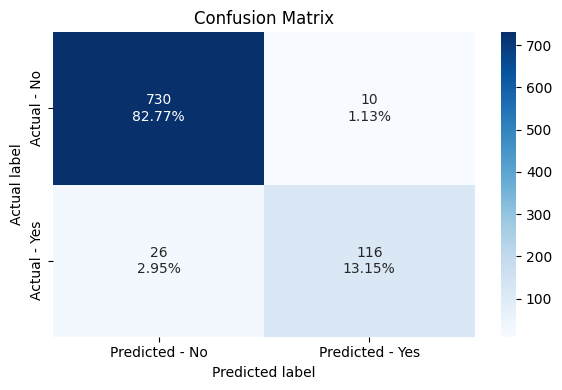

In [89]:
confusion_matrix_sklearn(bagging_estimator, X_test,y_test)

In [90]:
bagging_estimator_model_train_perf=model_performance_classification_sklearn(bagging_estimator, X_train,y_train)
print("Training performance \n",bagging_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [91]:
bagging_estimator_model_test_perf=model_performance_classification_sklearn(bagging_estimator, X_test, y_test)
print("Testing performance \n",bagging_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.959184  0.816901   0.920635  0.865672


* Recall has improved but the accuracy and precision of the model has dropped drastically which is an indication that overall the model is making many mistakes.

### 8. Tuning Random Forest

In [92]:
# Choose the type of classifier. 
rf_estimator = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {  
        "n_estimators": [110,251,501],
        "min_samples_leaf": np.arange(1, 6,1),
        "max_features": [0.7,0.9,'log2','auto'],
        "max_samples": [0.7,0.9,None],
}

# Run the grid search
grid_obj = GridSearchCV(rf_estimator, parameters, scoring='recall',cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
rf_estimator.fit(X_train, y_train)

,n_estimators,110
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,np.int64(1)
,min_weight_fraction_leaf,0.0
,max_features,0.9
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


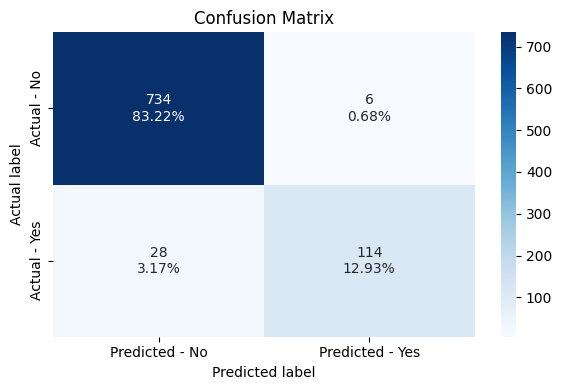

In [93]:
confusion_matrix_sklearn(rf_estimator, X_test,y_test)

In [94]:
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator, X_train,y_train)
print("Training performance \n",rf_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [95]:
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator, X_test, y_test)
print("Testing performance \n",rf_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.961451  0.802817       0.95  0.870229


* Random forest after tuning has given same performance as un-tuned random forest.

### Comparing all the models

In [96]:
# training performance comparison

models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T,bagging_model_train_perf.T, bagging_wt_model_train_perf.T,rf_model_train_perf.T,
    rf_wt_model_train_perf.T,dtree_estimator_model_train_perf.T, bagging_estimator_model_train_perf.T,
     rf_estimator_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Weighted Bagging Classifier",
    "Random Forest Classifier",
    "Weighted Random Forest Classifier",
    "Decision Tree Estimator",
    "Bagging Estimator",
    "Random Forest Estimator"]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree,1.000000,1.000000,1.0,1.000000
Bagging Classifier,0.993197,0.957831,1.0,0.978462
Weighted Bagging Classifier,0.993197,0.957831,1.0,0.978462
Random Forest Classifier,1.000000,1.000000,1.0,1.000000
Weighted Random Forest Classifier,1.000000,1.000000,1.0,1.000000
Decision Tree Estimator,0.996599,0.978916,1.0,0.989346
Bagging Estimator,1.000000,1.000000,1.0,1.000000
Random Forest Estimator,1.000000,1.000000,1.0,1.000000


In [97]:
# training performance comparison

models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T,bagging_model_test_perf.T, bagging_wt_model_test_perf.T,rf_model_test_perf.T,
    rf_wt_model_test_perf.T,dtree_estimator_model_test_perf.T, bagging_estimator_model_test_perf.T,
     rf_estimator_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Weighted Bagging Classifier",
    "Random Forest Classifier",
    "Weighted Random Forest Classifier",
    "Decision Tree Estimator",
    "Bagging Estimator",
    "Random Forest Estimator"]
print("Testing performance comparison:")
models_test_comp_df.T

Testing performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree,0.936508,0.830986,0.786667,0.808219
Bagging Classifier,0.945578,0.704225,0.943396,0.806452
Weighted Bagging Classifier,0.941043,0.704225,0.909091,0.793651
Random Forest Classifier,0.961451,0.802817,0.950000,0.870229
Weighted Random Forest Classifier,0.963719,0.788732,0.982456,0.875000
Decision Tree Estimator,0.939909,0.809859,0.815603,0.812721
Bagging Estimator,0.959184,0.816901,0.920635,0.865672
Random Forest Estimator,0.961451,0.802817,0.950000,0.870229


* Decision tree performed well on training and test set.
* Bagging classifier performed better than Decision Tree. 
* Random Forest with default parameters performed same as after tuning - As the final results depend on the parameters used/checked using GridSearchCV, There may be yet better parameters which may result in a better performance.

### Feature importance of Random Forest

In [98]:
# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(rf.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                        Imp
MonthlyIncome                      0.081224
OverTime_Yes                       0.059034
Age                                0.055639
DailyRate                          0.052808
TotalWorkingYears                  0.052409
HourlyRate                         0.050182
MonthlyRate                        0.048448
DistanceFromHome                   0.047190
YearsAtCompany                     0.039396
PercentSalaryHike                  0.031811
YearsWithCurrManager               0.030837
YearsInCurrentRole                 0.029495
NumCompaniesWorked                 0.028995
TrainingTimesLastYear              0.028378
EnvironmentSatisfaction            0.026274
JobInvolvement                     0.025814
StockOptionLevel                   0.025753
JobSatisfaction                    0.025293
WorkLifeBalance                    0.025217
JobLevel                           0.024070
YearsSinceLastPromotion            0.023860
Education                       

In [99]:
feature_names = X_train.columns

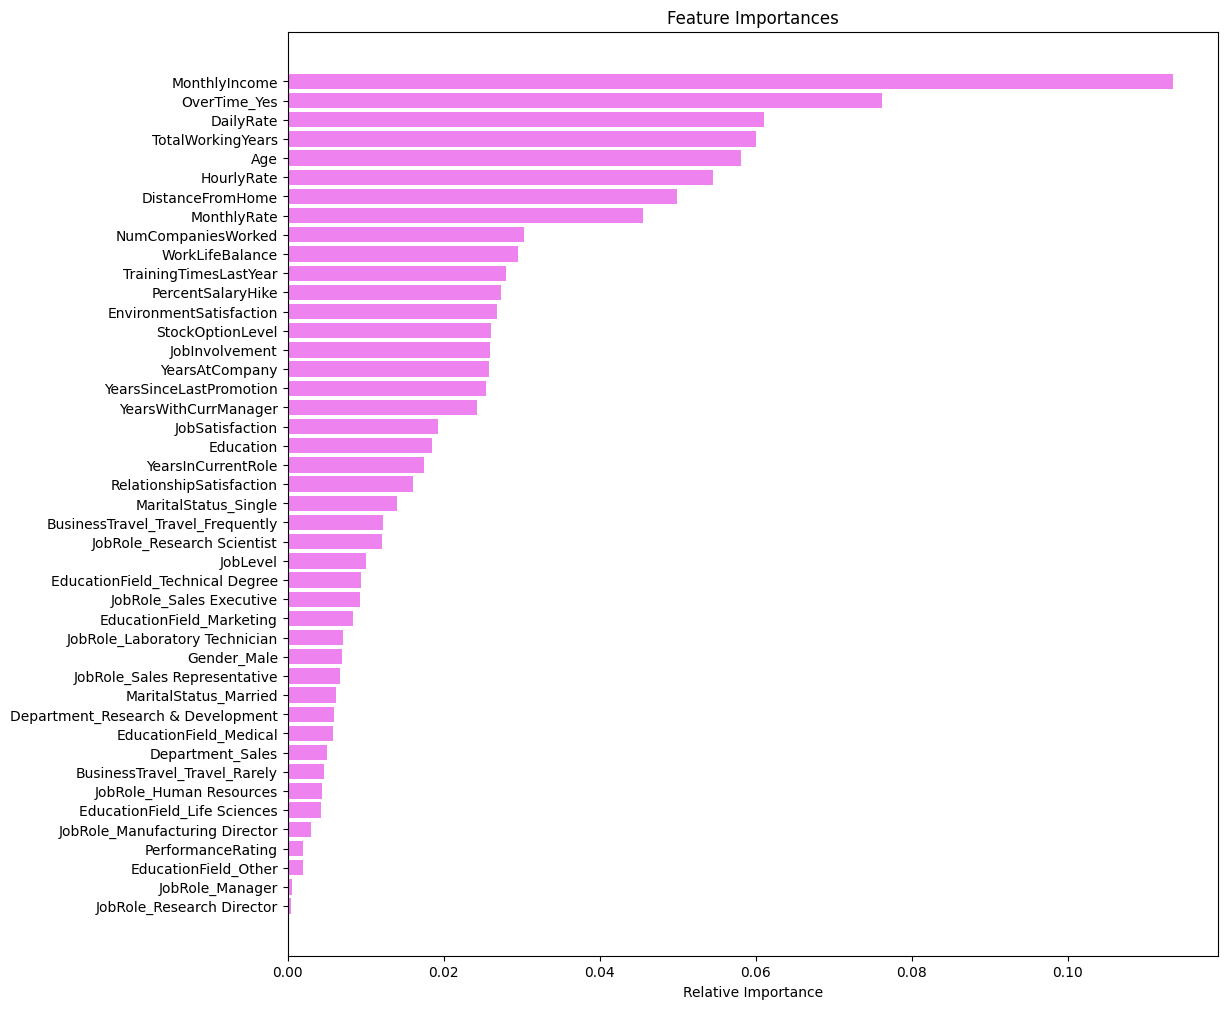

In [100]:
importances = rf_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

* Monthly income is the most important feature for prediction followed by Overtime, Daily Rate and Age.

### Business Insights and Recommendations

* We have been able to build a predictive model:
  a) that company can deploy this model to identify employees who are at the risk of attrition.
  b) that company can use to find the drivers of attrition. 
  c) based on which company can take appropriate actions to build better retention policies. 

* Factors that drive attrition - Monthly Income, Overtime, and Age.
* Monthly Income: Employees with lower income attrite more, which is also logical as they might get offers with higher pay in different organizations - the company should make sure that all employees are compensated based on industry standards.

* Overtime: Those employees who have to work overtime are the ones who attrite more - the company can provide some additional incentives to such employees to retain them.

* Age: Younger employees are the ones that attrite more- the company can make sure the new joiners have a friendly environment and better opportunities for excelling in their career.

* Distance From home is also an important factor for attrition - employees traveling more distance to reach the workplace are the ones attriting. For such employees, the company can provide cab facilities so that the commute of employees gets easier. 

* As work-related travel frequency increases, Attrition rate also increases - the company should 

* Training doesn't seem to have an impact on attrition- the company needs to investigate more here, if training does not impact employee retention then better cost planning can be done.

* Employee with more experience and the employees working for most years in the company is the loyal one's and generally do not attrite.

* Highest attrition is in the Sales department more research should go into this to check what is wrong in the sales department?

* Our data collection technique is working well as the ratings given by employees in -Environment Satisfaction, Job Satisfaction, Relationship Satisfaction, and Work-Life Balance shows a difference significant difference between attriting and non-attriting employees. These scales can act as a preliminary step to understand the dissatisfaction of employees - Lower the rating higher are the chances of attrition.